# 🧪 Pruebas A/B (A/B Testing)

## 🧠 ¿Qué es una prueba A/B?

Una **prueba A/B** es un experimento controlado donde se comparan **dos versiones** de algo:

- **A (control)**: versión actual
- **B (tratamiento)**: versión nueva

El objetivo es medir si B mejora un **indicador clave** (KPI) respecto a A, usando estadística inferencial para decidir si la diferencia observada es real o producto del azar.

---

## 🎯 Casos típicos de uso

- **Marketing / Growth:** CTR de anuncios, conversión de landing pages
- **Producto:** cambios en UI/UX, nuevos flujos de pago
- **E-commerce:** precios, promociones, recomendaciones
- **Educación:** método de enseñanza A vs B (nota promedio, tasa de aprobación)

---

## 📌 Conceptos clave

### ✅ Métrica (KPI)
La variable que medirás: conversión, clic, tiempo en página, ingreso por usuario, etc.

### ✅ Asignación aleatoria
Los usuarios se asignan aleatoriamente a A o B para evitar sesgos.

### ✅ Hipótesis
- **H₀:** no hay diferencia entre A y B  
- **H₁:** sí hay diferencia (o B es mejor que A)

### ✅ Valor p y significancia (α)
- α típico: 0.05  
- Si **p < α** → rechazo H₀ (evidencia de diferencia)

---

## 🧩 ¿Qué prueba estadística usar?

Depende del tipo de métrica:

### 1) Conversión / CTR (Binaria: 0/1)
✅ **Z-test de proporciones** (o chi-cuadrado)  
Ej: conversión (compra: sí/no), click (sí/no)

### 2) Métrica continua
✅ **t-test** (promedios)  
Ej: ticket promedio, tiempo de sesión, revenue

# 📌 1 - HIPOTESIS

# 🧪 A/B Testing con el dataset `tips` (Seaborn)

**Objetivo:** comparar si el % de propina cambia entre dos grupos:

- **Grupo A (Control):** Lunch
- **Grupo B (Tratamiento):** Dinner

**Métrica:** tip_percent = tip / total_bill

**Hipótesis:**
- H₀: μ_A = μ_B  (mismo promedio de tip_percent)
- H₁: μ_A ≠ μ_B  (promedios diferentes)

Nivel de significancia: α = 0.05

# 📌 2 — Cargar dataset y librerías

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# 📌 3 — Preparación de la métrica

In [2]:
# Creamos la métrica de interés: porcentaje de propina
df = df.copy()
df["tip_percent"] = df["tip"] / df["total_bill"]

df[["total_bill", "tip", "tip_percent", "time"]].head()

,total_bill,tip,tip_percent,time
0,16.99,1.01,0.059447,Dinner
1,10.34,1.66,0.160542,Dinner
2,21.01,3.50,0.166587,Dinner
3,23.68,3.31,0.139780,Dinner
4,24.59,3.61,0.146808,Dinner


# 📌 4 — Definir grupos A y B

In [3]:
A = df[df["time"] == "Lunch"]["tip_percent"].dropna()
B = df[df["time"] == "Dinner"]["tip_percent"].dropna()

print("n(A) Lunch:", len(A))
print("n(B) Dinner:", len(B))
print("Media A:", A.mean())
print("Media B:", B.mean())

n(A) Lunch: 68
n(B) Dinner: 176
Media A: 0.164127928162505
Media B: 0.15951778877977735


# 📌 5 — Visualización rápida

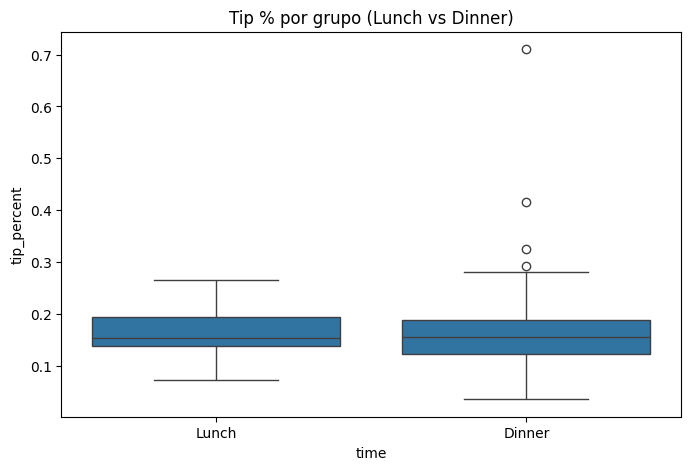

In [4]:
plt.figure(figsize=(8,5))
sns.boxplot(x="time", y="tip_percent", data=df)
plt.title("Tip % por grupo (Lunch vs Dinner)")
plt.show()

# 📌 6 — Prueba estadística (t-test de Welch)

In [5]:
t_stat, p_value = stats.ttest_ind(A, B, equal_var=False)

print(f"t-stat: {t_stat:.3f}")

if p_value < 0.001:
    print("p-value: < 0.001")
else:
    print(f"p-value: {p_value:.4f}")

t-stat: 0.654
p-value: 0.5138


# 📌 7 — Decisión

In [6]:
alpha = 0.05
decision = "RECHAZAR H0 (hay diferencia)" if p_value < alpha else "NO rechazar H0 (no hay evidencia de diferencia)"
print("Decisión:", decision)

Decisión: NO rechazar H0 (no hay evidencia de diferencia)
